# **Nearest Neighbour (NN) analysis for ASHES observations.**

- Computes NN for 2D positions of cores identified in ASHES.
- Plots histogram of NN lengths.
- Plots NN connections overlaid on ASHES 1.3 continuum map for one source (G024.52).

Produces the following from Barnes et al. (2026): 

- **Fig 1**: Example of a 1.3 mm continuum image from the ASHES sur-
vey (Morii et al. 2023), overlaid with the nearest-neighbour (NN) graph
(orange lines). The background colour scale and contours show the
ALMA 12 m + 7 m continuum emission, with contour levels at 3 × 2 nσ
(n = 0, 1, 2, . . . ), where σ = 9.5 × 10−5 Jy beam−1 is the rms noise level.
Detected core positions are marked by orange circles, and the scale bar
in the lower left corresponds to 0.1 pc at the assumed distance of 5.5 kpc.

- **Fig 9**: Effect of projection and resolution corrections on the distribution
of nearest–neighbour (NN) separations in the ASHES survey (Morii
et al. 2024). Top: Observed (projected) 2D separations. Middle: Sep-
arations corrected for projection bias using the sample–size–dependent
relation C(N) (Eq. 7). Bottom: Separations corrected for both projec-
tion and finite angular resolution using C(N, SDR) (Eq. 6). Dashed lines
mark the median values in each panel. The uncorrected distribution
peaks near 0.08 pc, increasing to 0.12 pc after applying C(N) but re-
turning to 0.07 pc when the finite dynamic range (SDR ∼ 10–20, de-
fined as clump radius to beam FWHM) is included. This demonstrates
the competing influences of geometric projection, which lengthens ap-
parent separations, and beam blending, which suppresses the shortest
scales (note caveats of applying to observations in Sect. 5.3)
>

In [ ]:
# Core scientific imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Astronomy imports
import aplpy
from astropy import units as u
from astropy import constants as const
from astropy.coordinates import SkyCoord
from astropy.io import fits

# corespaceing3d imports
from corespaceing3d.utils.compute_nn_mst import compute_nn
from corespaceing3d.plotting.utils import make_binary_tail_cmap

In [2]:
df_cl = pd.read_csv('../data/core/ashes/tables/clinfo.csv', index_col=0)

nns_sep_ori = []
nns_sep_4pi = []
nns_sep_C = []
nns_sep_CDyn = []

nns_sep_LJ_ori = []
nns_sep_LJ_4pi = []
nns_sep_LJ_C = []
nns_sep_LJ_CDyn = []

count=0
for region in df_cl.index:
    d = df_cl['d'][region]*u.kpc
    M_cl = df_cl['M_fit'][region]*u.Msun
    R_cl = df_cl['R_fit_pc'][region]*u.pc
    T = df_cl["T"][region] *u.K
    res = d.to('pc') / 206265
    SDR = (R_cl / res).value

    dendro = pd.read_csv('../data/core/ashes/tables/%s.csv'%region, index_col=0)
    Ncore = len(dendro)

    print(f"region = {region}, SDR = {SDR:.1f}, Ncore = {Ncore}")

    rho = (3*M_cl/4/np.pi/R_cl**3).to(u.g/u.cm**3)
    sigma_th = np.sqrt(const.k_B*T/2.37/const.m_p)
    LJ = (sigma_th * np.sqrt(np.pi/const.G/rho)).to(u.pc).value

    pos_x = dendro['peak_x']
    pos_y = dendro['peak_y']
    core_pos = []
    for a in dendro.index:
        core_pos.append([pos_x[a], pos_y[a]])

    l_obs, edges_obs, set_obs, len_obs, stats_obs = compute_nn(np.array(core_pos))
    pix_to_au = 5.833333333333E-05*3600 * (d.to(u.pc)).value *u.au

    C = 1.94 * (Ncore/100)**(0.173)

    CDyn  = 1.94 * (1 - np.exp(-SDR/21.8)) * (Ncore/100)**(0.173)

    len_pc_original =  ((len_obs * pix_to_au).to(u.pc)).value
    len_pc_4pi =  ((len_obs * pix_to_au).to(u.pc)).value / (np.pi/4)
    len_pc_C =  ((len_obs * pix_to_au).to(u.pc)).value * C
    len_pc_CDyn =  ((len_obs * pix_to_au).to(u.pc)).value * CDyn

    for j in range(len(len_obs)):
        nns_sep_ori.append(len_pc_original[j])
        nns_sep_4pi.append(len_pc_4pi[j])
        nns_sep_C.append(len_pc_C[j])
        nns_sep_CDyn.append(len_pc_CDyn[j])

region = G010.99, SDR = 27.3, Ncore = 28
region = G014.49, SDR = 23.1, Ncore = 37
region = G015.20, SDR = 23.1, Ncore = 26
region = G016.97, SDR = 14.8, Ncore = 13
region = G018.80, SDR = 31.8, Ncore = 8
region = G018.93, SDR = 43.3, Ncore = 15
region = G022.25, SDR = 12.6, Ncore = 16
region = G022.69, SDR = 16.6, Ncore = 12
region = G023.47, SDR = 14.6, Ncore = 19
region = G024.01, SDR = 9.4, Ncore = 16
region = G024.52, SDR = 28.6, Ncore = 23
region = G025.16, SDR = 22.7, Ncore = 18
region = G028.27, SDR = 19.3, Ncore = 19
region = G028.54, SDR = 24.5, Ncore = 18
region = G028.56, SDR = 22.8, Ncore = 35
region = G028.92, SDR = 16.1, Ncore = 9
region = G030.70, SDR = 26.4, Ncore = 21
region = G030.91, SDR = 15.9, Ncore = 12
region = G033.33, SDR = 19.2, Ncore = 9
region = G034.13, SDR = 29.6, Ncore = 15
region = G034.16, SDR = 20.8, Ncore = 22
region = G034.73, SDR = 14.5, Ncore = 24
region = G036.66, SDR = 14.8, Ncore = 13
region = G305.79, SDR = 13.4, Ncore = 34
region = G327.11, SD

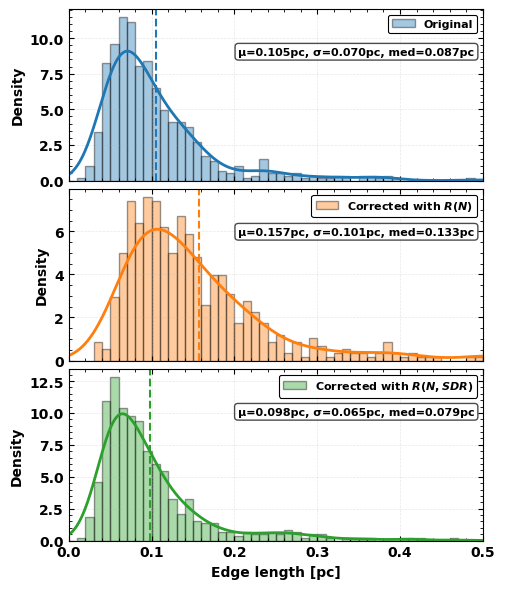

In [3]:
def plot_length_histogram(ax, len: np.ndarray, bins=20, color='tab:orange', label=""):
    """
    Fancy histogram + KDE overlay for 3D vs 2D MST edge lengths.
    """

    # Shared bins
    if isinstance(bins, int):
        bins = np.linspace(len.min(), len.max(), bins + 1)

    # Plot histograms
    ax.hist(len, bins=bins, color=color, alpha=0.4, edgecolor='black',
            density=True, label=label)

    # KDEs
    x_grid = np.linspace(bins.min(), bins.max(), 500)
    kde = gaussian_kde(len)
    ax.plot(x_grid, kde(x_grid), color=color, lw=2)

    # Means
    mean, med, sigma = len.mean(), np.median(len), np.nanstd(len)
    ax.axvline(mean, color=color, linestyle='--', lw=1.5)

    stats_text = (f"μ={mean:.3f}pc, σ={sigma:.3f}pc, med={med:.3f}pc")
    ax.text(0.98, 0.78, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    return ax

fig = plt.figure(figsize=(5, 6))
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)

bins = np.arange(0, 0.55, 0.01)
plot_length_histogram(ax1, np.array(nns_sep_ori), bins=bins, color='C0', label="Original")
plot_length_histogram(ax2, np.array(nns_sep_C), bins=bins, color='C1', label="Corrected with $R(N)$")
plot_length_histogram(ax3, np.array(nns_sep_CDyn), bins=bins, color='C2', label="Corrected with $R(N, SDR)$")

for ax in [ax1, ax2, ax3]:

    leg = ax.legend(prop={'size': 8}, facecolor='white', framealpha=1, loc="upper right")
    frame = leg.get_frame()
    frame.set_edgecolor('black')
    frame.set_linewidth(0.8)

    ax.set_ylabel("Density")
    ax.set_xlim(0, 0.5)
    ax.grid()

ax1.set_xticklabels([])
ax2.set_xticklabels([])

ax3.set_xlabel("Edge length [pc]")

fig.tight_layout(h_pad=0)
fig.savefig('../figures/nn_ashes.pdf', dpi=300)

In [4]:
def print_nn_stats(nns_sep_ori, nns_sep_C, nns_sep_CDyn):
    def stats(arr, label):
        arr = np.array(arr)
        print(f"\n--- {label} ---")
        print(f"N points: {len(arr)}")
        print(f"Mean separation: {np.mean(arr):.4f}")
        print(f"Median separation: {np.median(arr):.4f}")
        print(f"Std deviation: {np.std(arr):.4f}")
        print(f"Min–Max: {np.min(arr):.4f} – {np.max(arr):.4f}")
        return np.mean(arr), np.median(arr)

    m_ori, med_ori = stats(nns_sep_ori, "Original (2D)")
    m_C, med_C = stats(nns_sep_C, "Corrected with R(N)")
    m_CDyn, med_CDyn = stats(nns_sep_CDyn, "Corrected with R(N, SDR)")

    print("\n--- Derived Ratios ---")
    print(f"Mean ratio  R(N) / original  = {m_C / m_ori:.3f}")
    print(f"Mean ratio  R(N,SDR) / original  = {m_CDyn / m_ori:.3f}")
    print(f"Median ratio R(N) / original = {med_C / med_ori:.3f}")
    print(f"Median ratio R(N,SDR) / original = {med_CDyn / med_ori:.3f}")
    print(f"Fractional difference (R(N,SDR) – R(N)) / R(N) = {(m_CDyn - m_C)/m_C:.3%}")

# Example usage (before plotting):
print_nn_stats(nns_sep_ori, nns_sep_C, nns_sep_CDyn)


--- Original (2D) ---
N points: 586
Mean separation: 0.1053
Median separation: 0.0869
Std deviation: 0.0704
Min–Max: 0.0198 – 0.5499

--- Corrected with R(N) ---
N points: 586
Mean separation: 0.1570
Median separation: 0.1329
Std deviation: 0.1012
Min–Max: 0.0304 – 0.8263

--- Corrected with R(N, SDR) ---
N points: 586
Mean separation: 0.0976
Median separation: 0.0793
Std deviation: 0.0649
Min–Max: 0.0165 – 0.4668

--- Derived Ratios ---
Mean ratio  R(N) / original  = 1.491
Mean ratio  R(N,SDR) / original  = 0.927
Median ratio R(N) / original = 1.529
Median ratio R(N,SDR) / original = 0.913
Fractional difference (R(N,SDR) – R(N)) / R(N) = -37.835%


INFO: Auto-setting vmax to  4.825e+00 [aplpy.core]


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


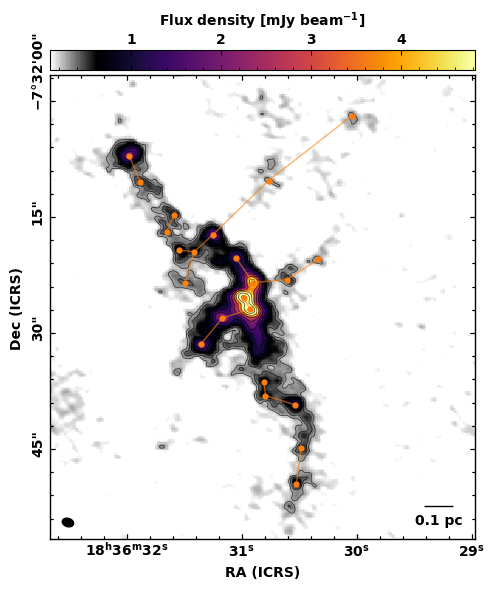

In [5]:
cont_map = fits.open('../data/core/ashes/maps/tG024.52.cont_1.33mm.12m7m.multiscale.image.mJy.fits')
dendro = pd.read_csv('../data/core/ashes/tables/G024.52.csv', index_col=0)

d_pc = 5500 # in pc
deg_01pc = ((0.1*u.pc).to(u.au)/d_pc/3600).value
rates = np.ones(12) * np.sqrt(2)

sigma_c = 9.48e-05
contlevel_c = sigma_c * 3 * rates ** np.arange(12)

fig = plt.figure(figsize=(6,6))
continuum1 = aplpy.FITSFigure(cont_map, figure=fig, subplot=(1,1,1))
continuum1.show_colorscale(cmap=make_binary_tail_cmap(), pmin=0.05, pmax=99.9, vmin=sigma_c*1e3, stretch ='linear')
continuum1.show_contour(data=cont_map[0].data, filled=False, colors='black', levels=contlevel_c*1e3, linewidths=0.5, alpha=0.75)

coords = SkyCoord('18h36m30.82s  -07d32m26.6859s', frame='icrs')
continuum1.recenter(coords.ra.deg, coords.dec.deg, height=(60*u.arcsec).to(u.deg).value, width=(55*u.arcsec).to(u.deg).value)

pos_x = dendro['peak_x']
pos_y = dendro['peak_y']
core_pos = []
for a in dendro.index:
    core_pos.append([pos_x[a], pos_y[a]])

l_obs, edges_obs, set_obs, len_obs, stats_obs = compute_nn(np.array(core_pos))

plt.scatter(pos_x, pos_y, s=12, fc="C1", ec="C1", zorder=12)

for i, j, _ in edges_obs:
    xs = [pos_x[i], pos_x[j]]
    ys = [pos_y[i], pos_y[j]]
    plt.plot(xs, ys, color='C1', alpha=0.6, linewidth=1, zorder=10)

continuum1.add_scalebar(length=deg_01pc, color='black')
continuum1.scalebar.set_label('0.1 pc')
continuum1.add_beam()
continuum1.beam.set_color('black')
continuum1.add_colorbar(location="top")
continuum1.colorbar.set_axis_label_text('Flux density [mJy beam$^{-1}$]')
continuum1.axis_labels.set_ytext('Dec (ICRS)')
continuum1.axis_labels.set_xtext('RA (ICRS)')

continuum1.ticks.set_color("black")
continuum1.ax.coords['dec'].set_ticklabel(rotation=90, ha='left', va='center')

fig.tight_layout()
plt.savefig('../figures/G024.52_nns.pdf', bbox_inches ='tight')